# Figure plot part 2

## 1 General settings

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import seaborn as sns
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['pdf.fonttype'] = 42

In [3]:
pal = {"Lenti-SIINFEKL":"#FF6982",
      "Lenti-mCherry":"#800020",
      "Lenti-Control":"#E6E6E6"}

In [4]:
mapping = {
    'NI': 'Lenti-Control',
    'MI': 'Lenti-mCherry',
    'HI': 'Lenti-SIINFEKL'
}

In [5]:
panel_order = ["Lenti-Control", "Lenti-mCherry", "Lenti-SIINFEKL"]

In [6]:
# color mapping between gene and color
color_list = sns.color_palette("tab20", 14) 
gene_list = ['Lkb1', 'Setd2', 'Rb1', 'Trp53', 'Apc', 'Rbm10', 'Smad4', 'Cdkn2a','PDL1', 'Inert', 'Arid1a', 'Atm', 'Keap1', 'B2M']
# Map the gene list to the color palette
gene_color_map = dict(zip(gene_list, color_list))

In [7]:
bt_summary_path = (
    "data/Adaptive_BT_gene_level_summary_df.csv"
)
bt_summary_df = pd.read_csv(bt_summary_path)

bt_summary_path2 = (
    "data/Normal_BT_gene_level_summary_df.csv"
)
bt_summary_df2 = pd.read_csv(bt_summary_path2)

relative_resistance_effect_path = (
    "data/Adaptive_treatment_gene_level_df.csv"
)
relative_resistance_effect_df = pd.read_csv(relative_resistance_effect_path)


relative_resistance_effect_path2 = (
    "data/Normal_treatment_gene_level_df.csv"
)
relative_resistance_effect_df2 = pd.read_csv(relative_resistance_effect_path2)

---

## 2 Tumor size barplot for control genes: Fig. 6A and Fig. S13A

In [8]:
query_gene_list = ['Inert','PDL1','B2M']
test_trait = ['Vector_type','Cutoff_method','Mouse_genotype','Targeted_gene_name']
query_df = bt_summary_df.merge(relative_resistance_effect_df, on=test_trait, how='left').copy()

/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/3498169580.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(
/Users/jasperx/miniforge3/envs/HX_basic/lib/python3.12/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/3498169580.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(
/Users/jasperx/miniforge3/envs/HX_basic/lib/python3.12/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

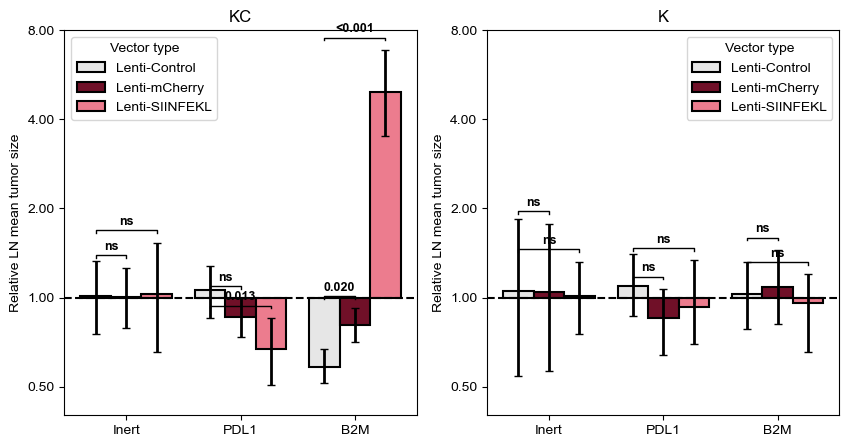

In [9]:
# Configuration parameters
trait_of_interest = 'LN_mean_relative'
temp_y_label_name = 'Relative LN mean tumor size'
median_trait_name = trait_of_interest + '_bootstrap_median'
test_df = query_df[(query_df.Targeted_gene_name.isin(query_gene_list))].copy()
p_value_matrics = f'{trait_of_interest}_fold_pvalue_twoside_FDR'
# colors_p = {'Neo':'grey', 'PDL1': 'blue', 'B2M':'red'}
# Sorting DataFrame
test_df['Targeted_gene_name'] = pd.Categorical(test_df['Targeted_gene_name'], ordered=True, categories=query_gene_list)
test_df['Vector_type'] = pd.Categorical(test_df['Vector_type'], ordered=True, categories=panel_order)
test_df = test_df.sort_values(by=['Vector_type', 'Targeted_gene_name'], ascending=[True, True]).copy()
y_max = 8
y_min = 0.4

# Set figure size
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# ... (previous configuration code)

# ... (your existing setup code)

for ax_idx, gt in enumerate(['KC', 'K']):
    ax1 = axes[ax_idx]
    input_df = test_df[test_df.Mouse_genotype == gt]
    
    barplot = sns.barplot(
        data=input_df,
        x='Targeted_gene_name',
        y=input_df[median_trait_name] - 1,
        hue='Vector_type',
        ax=ax1,
        ci=None,
        palette=pal,
        bottom=1,
        edgecolor='black',
        linewidth=1.5
    )

    # Calculate offsets for hue groups
    # Seaborn places hue bars at specific offsets from the integer x-tick
    n_hues = len(panel_order)
    width = 0.8 / n_hues # Default seaborn width is 0.8
    offsets = np.linspace(-0.4 + width/2, 0.4 - width/2, n_hues)
    hue_to_offset = dict(zip(panel_order, offsets))

    # Loop through each gene and its hue groups to draw your original error bars + new p-values
    for i, gene in enumerate(query_gene_list):
        # 1. Get the x-coordinate of the Lenti-Control bar (the reference)
        x_ref = i + hue_to_offset['Lenti-Control']
        
        gene_df = input_df[input_df['Targeted_gene_name'] == gene]
        
        for v_type in panel_order:
            df_row = gene_df[gene_df['Vector_type'] == v_type]
            if df_row.empty:
                continue

            # --- KEEPING YOUR ORIGINAL ERROR BAR LOGIC ---
            x = i + hue_to_offset[v_type]
            median_val = df_row[median_trait_name].values[0]
            low_error = median_val - df_row[trait_of_interest + '_2.5P'].values[0]
            high_error = df_row[trait_of_interest + '_97.5P'].values[0] - median_val
            
            ax1.errorbar(x, median_val, yerr=[[low_error], [high_error]], 
                         fmt='none', c='black', lw=2, capsize=3)
            # ---------------------------------------------

            # --- NEW P-VALUE BRACKET LOGIC ---
            p_val = df_row[p_value_matrics].values[0]
            
            # Skip Lenti-Control or rows with no p-value
            if v_type == 'Lenti-Control' or pd.isna(p_val):
                continue
            
            # Format significance label
            sig_label = 'ns' if p_val >= 0.1 else ('<0.001' if p_val < 0.001 else f'{p_val:.3f}')
            
            # Determine height (top of the error bar + a margin)
            # Using a multiplier because of the log scale
            y_annot_base = (median_val + high_error) * 1.1 
            
            # Draw the horizontal comparison line from ref to current bar
            ax1.plot([x_ref, x_ref, x, x], 
                     [y_annot_base * 0.98, y_annot_base, y_annot_base, y_annot_base * 0.98], 
                     color='black', lw=1)
            
            # Place p-value text
            ax1.text(
                (x_ref + x) / 2,
                y_annot_base * 1.02,
                sig_label,
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    ax1.set_ylim(y_min, y_max)
    ax1.set_title(gt)
    ax1.axhline(y=1, color='black', linestyle='--')
    ax1.set_ylabel(temp_y_label_name)
    ax1.set_xlabel('')
    ax1.legend(title='Vector type', ncol=1)
    ax1.set_yscale('log', base=2)
    
    # Updated tick handling for newer matplotlib versions
    ax1.yaxis.set_major_formatter(plt.ScalarFormatter())
plt.show()

---

## 3 Trait heat map for control genes: Fig. S13B

In [10]:
query_df = bt_summary_df.copy()
query_df = query_df[query_df.Mouse_genotype=='KC']
query_gene_list = ['Inert','PDL1','B2M']

In [11]:
query_trait_list = ['LN_mean_relative', '50_percentile_relative', '90_percentile_relative']

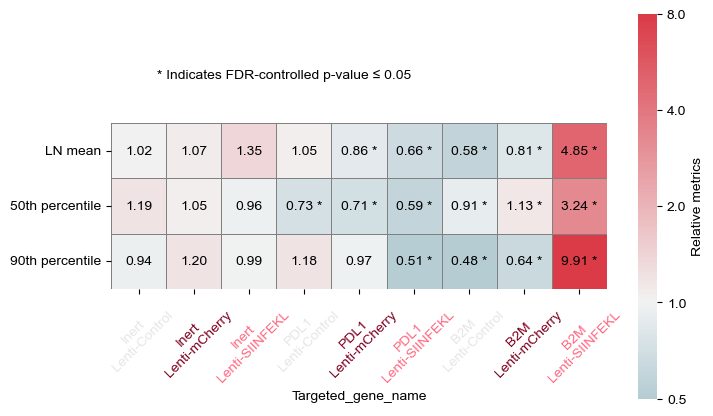

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.gridspec as gridspec
temp_input_df = query_df
temp_gene_list = query_gene_list
# Data processing steps
temp_input_df["Vector_type"] = pd.Categorical(temp_input_df["Vector_type"], categories=panel_order, ordered=True)
temp_input_df = temp_input_df.sort_values(["Vector_type", "Targeted_gene_name"])

input_df = np.log2(temp_input_df.set_index('Targeted_gene_name')[query_trait_list].transpose())[temp_gene_list]
input_df2 = temp_input_df.set_index('Targeted_gene_name')[query_trait_list].transpose()[temp_gene_list]

# Create the p-value matrix and mask
temp_new_list = [x + '_pvalue_twoside' for x in input_df.index]
temp_pvalue_matrix = temp_input_df.set_index('Targeted_gene_name')[temp_new_list].transpose()[temp_gene_list]
temp_mask = temp_pvalue_matrix > 0.05
temp_mask.index = input_df2.index
temp_mask.columns = input_df2.columns

annotations = input_df2.apply(lambda col: col.map(lambda x: f'{x:.2f}'))
annotations = annotations.where(temp_mask, annotations + ' *')

custom_row_labels = ['LN mean',  '50th percentile', '90th percentile']
# Prepare Vector_type colors based on the palette
vector_types = temp_input_df.set_index('Targeted_gene_name').loc[temp_gene_list, 'Vector_type']
vector_labels = vector_types.values  # Extract Vector_type values for each gene

# Plotting heatmap
fig1 = plt.figure(figsize=(8, 5))
gs = gridspec.GridSpec(11, 11)
ax1 = fig1.add_subplot(gs[:11, 0:11])

cmap = sns.diverging_palette(220, 10, as_cmap=True)

vmin = np.log2(0.5)   # = -1
vmax = np.log2(8)     # = 3

# 1. Draw the heatmap WITHOUT the annot parameter
heatmap = sns.heatmap(
    input_df,
    cmap=cmap,
    ax=ax1,
    center=0,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    square=True,
    xticklabels=True,
    yticklabels=custom_row_labels,
    cbar_kws={'label': 'Relative metrics'},
    linecolor='grey',
    annot=False  
)

# 2. Manually loop through the data and add the text from your 'annotations' df
for y in range(input_df.shape[0]):
    for x in range(input_df.shape[1]):
        # Get the text string from your perfect annotations dataframe
        label_text = annotations.iloc[y, x]
        
        # Add text to the center of each cell (x and y are indices)
        ax1.text(
            x + 0.5, 
            y + 0.5, 
            label_text, 
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=10,
            color='black',
            clip_on=False # Force it to show even if it touches the edge
        )

ax1.tick_params(axis='x', which='major', labelsize=10, rotation=45)
ax1.tick_params(axis='y', which='major', labelsize=10)
ax1.set_facecolor("grey")

# Modify the color bar to show original values before log2 transformation
colorbar = heatmap.collections[0].colorbar

# define ticks in original scale
original_ticks = np.array([0.5, 1, 2, 4, 8])

# convert to log2 positions
log_ticks = np.log2(original_ticks)

colorbar.set_ticks(log_ticks)
colorbar.set_ticklabels([str(x) for x in original_ticks])

# Set additional x-axis labels for Vector_type
ax1.set_xticklabels([
    f'{label.get_text()}\n{vector}' for label, vector in zip(ax1.get_xticklabels(), vector_labels)
])
# Color code the additional labels based on the `pal` dictionary
for label, vector in zip(ax1.get_xticklabels(), vector_labels):
    label.set_color(pal.get(vector, "black"))  # Default to black if the vector is not in pal

plt.figtext(0.5, 0.75, "* Indicates FDR-controlled p-value ≤ 0.05", fontsize=10, ha='right', color='black')

# fig1.savefig(temp_out_address7)
plt.show()


---

## 4 Tumor number Fig. S13C

In [13]:
query_df = bt_summary_df2.copy()
query_gene_list = ['Inert','PDL1','B2M']

/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/1959066074.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(
/Users/jasperx/miniforge3/envs/HX_basic/lib/python3.12/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/1959066074.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(
/Users/jasperx/miniforge3/envs/HX_basic/lib/python3.12/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

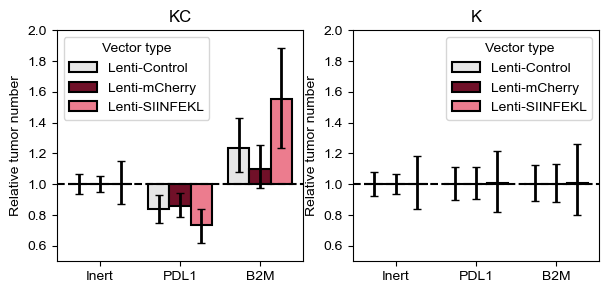

In [14]:
# Configuration parameters
trait_of_interest = 'TTN_normalized_relative'
temp_y_label_name = 'Relative tumor number'
median_trait_name = trait_of_interest+'_bootstrap_median'
test_df = query_df[(query_df.Targeted_gene_name.isin(query_gene_list))].copy()
# colors_p = {'Neo':'grey', 'PDL1': 'blue', 'B2M':'red'}
# Sorting DataFrame
test_df['Targeted_gene_name'] = pd.Categorical(test_df['Targeted_gene_name'], ordered=True, categories=query_gene_list)
test_df['Vector_type'] = pd.Categorical(test_df['Vector_type'], ordered=True, categories=panel_order)
test_df = test_df.sort_values(by=['Vector_type','Targeted_gene_name'], ascending=[True, True]).copy() # it is critical to sort targeted_gene_name first and genotype later because here the x aixs is mouse genotyp while hue is targeted_gen_name

y_max = 2
y_min = 0.5

# Set figure size
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Loop through each Vector_type in the specified order and create a subplot
for i, gt in enumerate(['KC','K']):
    ax1 = axes[i]
    input_df = test_df[test_df.Mouse_genotype==gt]
    # Plotting barplot using seaborn
    barplot = sns.barplot(
        data=input_df,
        x='Targeted_gene_name',
        y=input_df[median_trait_name] - 1,
        hue='Vector_type',
        ax=ax1,
        ci=None,
        palette=pal,
        bottom=1,
        edgecolor='black',  # Set the edge color of the bars
        linewidth=1.5       # Set the width of the edge (bar border)
    )

    # Adding error bars
    for i, patch in enumerate(barplot.patches):
        # Get the x position of the bar
        x = patch.get_x() + patch.get_width() / 2

        # Find the corresponding row in the DataFrame
        genotype = input_df['Vector_type'].values[i]
        gene = input_df['Targeted_gene_name'].values[i]

        df_row = input_df[(input_df['Targeted_gene_name'] == gene) & (input_df['Vector_type'] == genotype)]
        # Get the mean and error values
        median_val = df_row[median_trait_name].values[0]
        low_error = median_val - df_row[trait_of_interest+'_2.5P'].values[0]
        high_error = df_row[trait_of_interest+'_97.5P'].values[0] - median_val

        # Plot the error bars
        ax1.errorbar(x, median_val, yerr=[[low_error], [high_error]], fmt='none', c='black', lw=2, capsize=3)
    ax1.set_ylim(y_min,y_max)
    ax1.set_title(gt)
    # Add horizontal line at y=1
    ax1.axhline(y=1, color='black', linestyle='--')

    # Set labels
    ax1.set_ylabel(temp_y_label_name)
    ax1.set_xlabel('')
    ax1.legend(title='Vector type', ncol=1)

# Show plot
plt.show()

In [15]:
# query_gene_list = ['Inert','PDL1','B2M']
# test_trait = ['Vector_type','Cutoff_method','Mouse_genotype','Targeted_gene_name']
# query_df = bt_summary_df2.merge(relative_resistance_effect_df2, on=test_trait, how='left').copy()
# # Configuration parameters
# trait_of_interest = 'TTN_normalized_relative'
# temp_y_label_name = 'Relative tumor number'
# median_trait_name = trait_of_interest+'_bootstrap_median'
# test_df = query_df[(query_df.Targeted_gene_name.isin(query_gene_list))].copy()
# p_value_matrics = f'{trait_of_interest}_fold_pvalue_twoside_FDR'
# # colors_p = {'Neo':'grey', 'PDL1': 'blue', 'B2M':'red'}
# # Sorting DataFrame
# test_df['Targeted_gene_name'] = pd.Categorical(test_df['Targeted_gene_name'], ordered=True, categories=query_gene_list)
# test_df['Vector_type'] = pd.Categorical(test_df['Vector_type'], ordered=True, categories=panel_order)
# test_df = test_df.sort_values(by=['Vector_type', 'Targeted_gene_name'], ascending=[True, True]).copy()
# y_max = 2
# y_min = 0.4

# # Set figure size
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# for ax_idx, gt in enumerate(['KC', 'K']):
#     ax1 = axes[ax_idx]
#     input_df = test_df[test_df.Mouse_genotype == gt]
    
#     barplot = sns.barplot(
#         data=input_df,
#         x='Targeted_gene_name',
#         y=input_df[median_trait_name] - 1,
#         hue='Vector_type',
#         ax=ax1,
#         ci=None,
#         palette=pal,
#         bottom=1,
#         edgecolor='black',
#         linewidth=1.5
#     )

#     # Calculate offsets for hue groups
#     # Seaborn places hue bars at specific offsets from the integer x-tick
#     n_hues = len(panel_order)
#     width = 0.8 / n_hues # Default seaborn width is 0.8
#     offsets = np.linspace(-0.4 + width/2, 0.4 - width/2, n_hues)
#     hue_to_offset = dict(zip(panel_order, offsets))

#     # Loop through each gene and its hue groups to draw your original error bars + new p-values
#     for i, gene in enumerate(query_gene_list):
#         # 1. Get the x-coordinate of the Lenti-Control bar (the reference)
#         x_ref = i + hue_to_offset['Lenti-Control']
        
#         gene_df = input_df[input_df['Targeted_gene_name'] == gene]
        
#         for v_type in panel_order:
#             df_row = gene_df[gene_df['Vector_type'] == v_type]
#             if df_row.empty:
#                 continue

#             # --- KEEPING YOUR ORIGINAL ERROR BAR LOGIC ---
#             x = i + hue_to_offset[v_type]
#             median_val = df_row[median_trait_name].values[0]
#             low_error = median_val - df_row[trait_of_interest + '_2.5P'].values[0]
#             high_error = df_row[trait_of_interest + '_97.5P'].values[0] - median_val
            
#             ax1.errorbar(x, median_val, yerr=[[low_error], [high_error]], 
#                          fmt='none', c='black', lw=2, capsize=3)
#             # ---------------------------------------------

#             # --- NEW P-VALUE BRACKET LOGIC ---
#             p_val = df_row[p_value_matrics].values[0]
            
#             # Skip Lenti-Control or rows with no p-value
#             if v_type == 'Lenti-Control' or pd.isna(p_val):
#                 continue
            
#             # Format significance label
#             sig_label = 'ns' if p_val >= 0.1 else ('<0.001' if p_val < 0.001 else f'{p_val:.3f}')
            
#             # Determine height (top of the error bar + a margin)
#             # Using a multiplier because of the log scale
#             y_annot_base = (median_val + high_error) * 1.1 
            
#             # Draw the horizontal comparison line from ref to current bar
#             ax1.plot([x_ref, x_ref, x, x], 
#                      [y_annot_base * 0.98, y_annot_base, y_annot_base, y_annot_base * 0.98], 
#                      color='black', lw=1)
            
#             # Place p-value text
#             ax1.text(
#                 (x_ref + x) / 2,
#                 y_annot_base * 1.02,
#                 sig_label,
#                 ha='center',
#                 va='bottom',
#                 fontsize=9,
#                 fontweight='bold'
#             )

#     ax1.set_ylim(y_min, y_max)
#     ax1.set_title(gt)
#     ax1.axhline(y=1, color='black', linestyle='--')
#     ax1.set_ylabel(temp_y_label_name)
#     ax1.set_xlabel('')
#     ax1.legend(title='Vector type', ncol=1)
#     # ax1.set_yscale('log', base=2)
    
#     # Updated tick handling for newer matplotlib versions
#     ax1.yaxis.set_major_formatter(plt.ScalarFormatter())
# plt.show()

----

## 5 Tumor size barplot for TSGs: Fig. 6B

In [16]:
query_gene_list = ['Inert','PDL1','B2M']
test_trait = ['Vector_type','Cutoff_method','Mouse_genotype','Targeted_gene_name']
query_df = bt_summary_df.merge(relative_resistance_effect_df, on=test_trait, how='left').copy()

In [17]:
query_gene_list = ['Lkb1','Setd2','Rb1','Trp53','Apc', 'Rbm10',
                   'Smad4','Cdkn2a','Arid1a','Atm','Keap1', 'Inert']

/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/2549354266.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(
/Users/jasperx/miniforge3/envs/HX_basic/lib/python3.12/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/2549354266.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  barplot = sns.barplot(
/Users/jasperx/miniforge3/envs/HX_basic/lib/python3.12/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

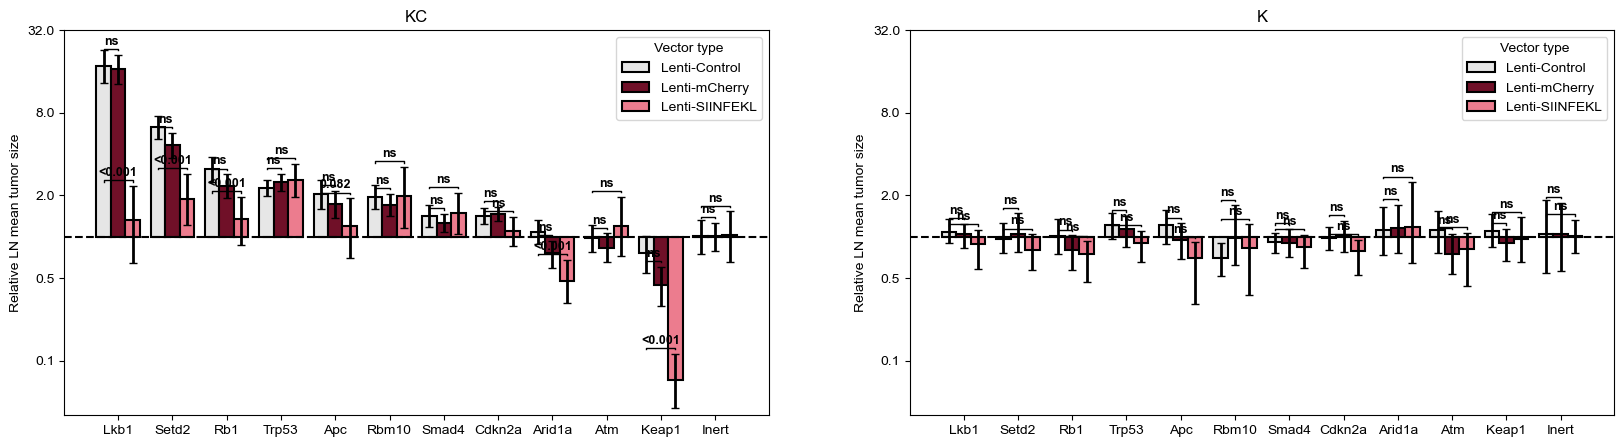

In [18]:
# Configuration parameters
trait_of_interest = 'LN_mean_relative'
temp_y_label_name = 'Relative LN mean tumor size'
median_trait_name = trait_of_interest+'_bootstrap_median'
test_df = query_df[(query_df.Targeted_gene_name.isin(query_gene_list))].copy()
p_value_matrics = f'{trait_of_interest}_fold_pvalue_twoside_FDR'
# colors_p = {'Neo':'grey', 'PDL1': 'blue', 'B2M':'red'}
# Sorting DataFrame
test_df['Targeted_gene_name'] = pd.Categorical(test_df['Targeted_gene_name'], ordered=True, categories=query_gene_list)
test_df['Vector_type'] = pd.Categorical(test_df['Vector_type'], ordered=True, categories=panel_order)
test_df = test_df.sort_values(by=['Vector_type','Targeted_gene_name'], ascending=[True, True]).copy() # it is critical to sort targeted_gene_name first and genotype later because here the x aixs is mouse genotyp while hue is targeted_gen_name

y_max = 32
y_min = 0.05

# Set figure size
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

for ax_idx, gt in enumerate(['KC', 'K']):
    ax1 = axes[ax_idx]
    input_df = test_df[test_df.Mouse_genotype == gt]
    
    barplot = sns.barplot(
        data=input_df,
        x='Targeted_gene_name',
        y=input_df[median_trait_name] - 1,
        hue='Vector_type',
        ax=ax1,
        ci=None,
        palette=pal,
        bottom=1,
        edgecolor='black',
        linewidth=1.5
    )

    # Calculate offsets for hue groups
    # Seaborn places hue bars at specific offsets from the integer x-tick
    n_hues = len(panel_order)
    width = 0.8 / n_hues # Default seaborn width is 0.8
    offsets = np.linspace(-0.4 + width/2, 0.4 - width/2, n_hues)
    hue_to_offset = dict(zip(panel_order, offsets))

    # Loop through each gene and its hue groups to draw your original error bars + new p-values
    for i, gene in enumerate(query_gene_list):
        # 1. Get the x-coordinate of the Lenti-Control bar (the reference)
        x_ref = i + hue_to_offset['Lenti-Control']
        
        gene_df = input_df[input_df['Targeted_gene_name'] == gene]
        
        for v_type in panel_order:
            df_row = gene_df[gene_df['Vector_type'] == v_type]
            if df_row.empty:
                continue

            # --- KEEPING YOUR ORIGINAL ERROR BAR LOGIC ---
            x = i + hue_to_offset[v_type]
            median_val = df_row[median_trait_name].values[0]
            low_error = median_val - df_row[trait_of_interest + '_2.5P'].values[0]
            high_error = df_row[trait_of_interest + '_97.5P'].values[0] - median_val
            
            ax1.errorbar(x, median_val, yerr=[[low_error], [high_error]], 
                         fmt='none', c='black', lw=2, capsize=3)
            # ---------------------------------------------

            # --- NEW P-VALUE BRACKET LOGIC ---
            p_val = df_row[p_value_matrics].values[0]
            
            # Skip Lenti-Control or rows with no p-value
            if v_type == 'Lenti-Control' or pd.isna(p_val):
                continue
            
            # Format significance label
            sig_label = 'ns' if p_val >= 0.1 else ('<0.001' if p_val < 0.001 else f'{p_val:.3f}')
            
            # Determine height (top of the error bar + a margin)
            # Using a multiplier because of the log scale
            y_annot_base = (median_val + high_error) * 1.1 
            
            # Draw the horizontal comparison line from ref to current bar
            ax1.plot([x_ref, x_ref, x, x], 
                     [y_annot_base * 0.98, y_annot_base, y_annot_base, y_annot_base * 0.98], 
                     color='black', lw=1)
            
            # Place p-value text
            ax1.text(
                (x_ref + x) / 2,
                y_annot_base * 1.02,
                sig_label,
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    ax1.set_ylim(y_min, y_max)
    ax1.set_title(gt)
    ax1.axhline(y=1, color='black', linestyle='--')
    ax1.set_ylabel(temp_y_label_name)
    ax1.set_xlabel('')
    ax1.legend(title='Vector type', ncol=1)
    ax1.set_yscale('log', base=2)
    
    # Updated tick handling for newer matplotlib versions
    ax1.yaxis.set_major_formatter(plt.ScalarFormatter())

# Show plot
plt.show()

---

## 6 Trait heat map for TSGs: Fig. S13BFig. S13F 

In [19]:
query_df = bt_summary_df.copy()
query_df = query_df[query_df.Mouse_genotype=='KC']
query_gene_list = ['Lkb1','Setd2','Rb1','Trp53','Apc', 'Rbm10',
                   'Smad4','Cdkn2a','Arid1a','Atm','Keap1', 'Inert']

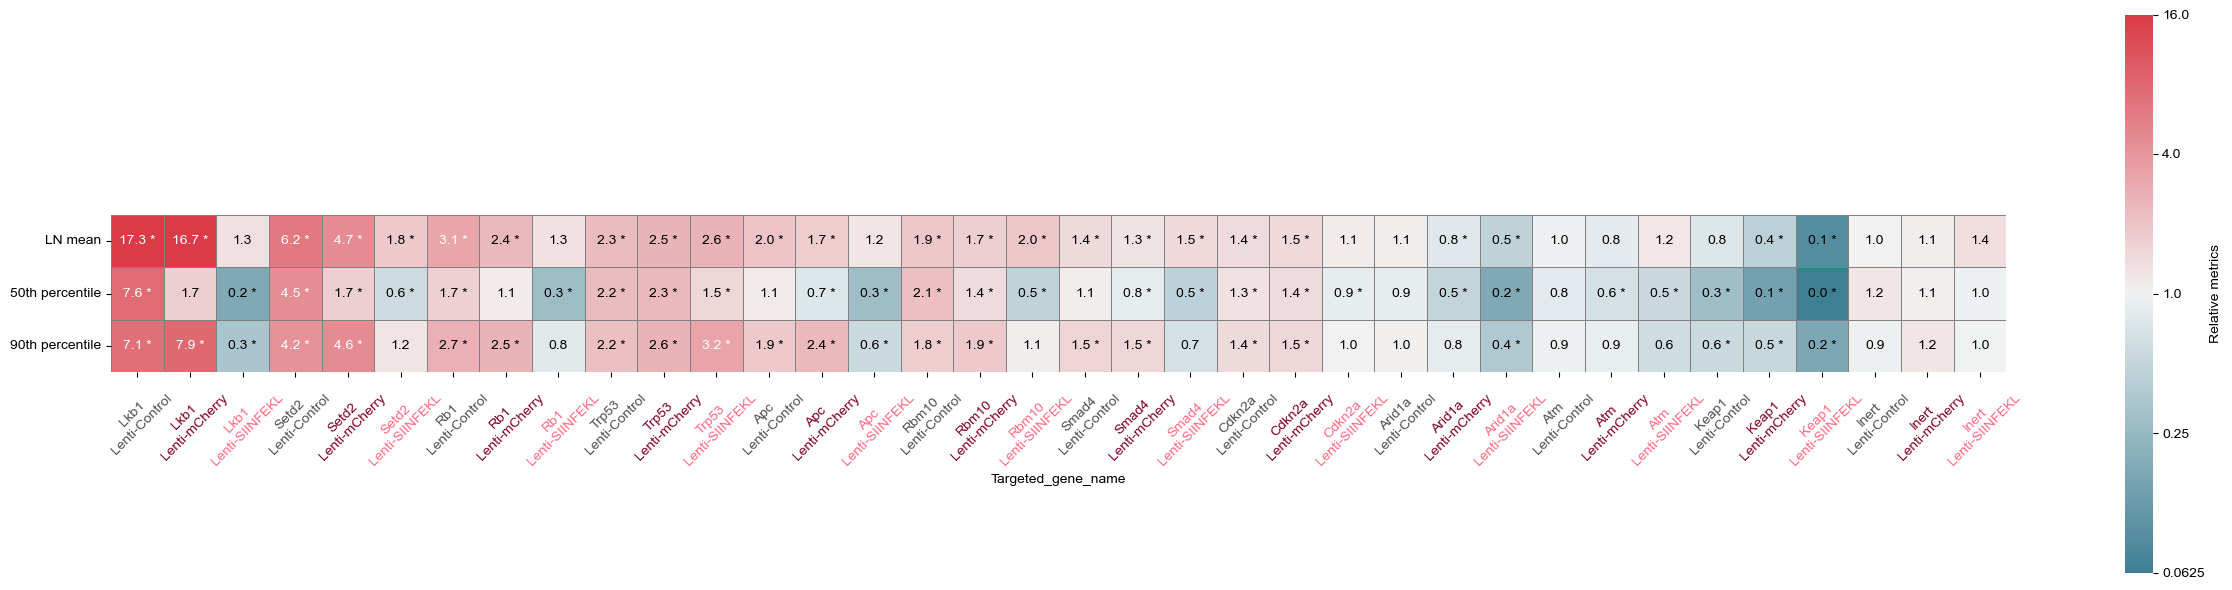

In [20]:
temp_input_df = query_df.copy()
temp_input_df["Vector_type"] = pd.Categorical(
    temp_input_df["Vector_type"],
    categories=panel_order,
    ordered=True
)
temp_input_df = temp_input_df.sort_values(["Vector_type", "Targeted_gene_name"])

temp = ['LN_mean_relative', '50_percentile_relative', '90_percentile_relative']
temp_gene_list = query_gene_list
custom_row_labels = ['LN mean', '50th percentile', '90th percentile']

pal = {
    "Lenti-SIINFEKL": "#FF6982",
    "Lenti-mCherry": "#800020",
    "Lenti-Control": "#4F4F4F"
}

# Data matrices
input_df = np.log2(
    temp_input_df.set_index('Targeted_gene_name')[temp].transpose()
)[temp_gene_list]

input_df2 = temp_input_df.set_index('Targeted_gene_name')[temp].transpose()[temp_gene_list]

# P-value matrix and mask
temp_new_list = [x + '_pvalue_twoside' for x in input_df.index]
temp_pvalue_matrix = temp_input_df.set_index('Targeted_gene_name')[temp_new_list].transpose()[temp_gene_list]
temp_mask = temp_pvalue_matrix > 0.05
temp_mask.index = input_df2.index
temp_mask.columns = input_df2.columns

# Annotation strings
annotations = input_df2.apply(lambda col: col.map(lambda x: f'{x:.1f}'))
annotations = annotations.where(temp_mask, annotations + ' *')

# Vector labels
vector_types = temp_input_df.set_index('Targeted_gene_name').loc[temp_gene_list, 'Vector_type']
vector_labels = vector_types.values

# Plot
fig, ax = plt.subplots(figsize=(25, 6))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

vmin = np.log2(0.0625)
vmax = np.log2(16)

heatmap = sns.heatmap(
    input_df,
    cmap=cmap,
    ax=ax,
    center=0,
    vmin=vmin,
    vmax=vmax,
    linewidths=0.5,
    square=True,
    xticklabels=True,
    yticklabels=custom_row_labels,
    cbar_kws={'label': 'Relative metrics'},
    linecolor='grey'
)

# Manual annotation
for i in range(input_df.shape[0]):
    for j in range(input_df.shape[1]):
        txt = annotations.iat[i, j]
        ax.text(
            j + 0.5, i + 0.5, txt,
            ha='center',
            va='center',
            fontsize=10,
            color='white' if input_df.iat[i, j] > np.log2(3) else 'black'
        )

# Axis styling
ax.tick_params(axis='x', which='major', labelsize=10, rotation=45)
ax.tick_params(axis='y', which='major', labelsize=10)

# Keep your original bottom tick labeling style
ax.set_xticklabels([
    f'{label.get_text()}\n{vector}'
    for label, vector in zip(ax.get_xticklabels(), vector_labels)
])

for label, vector in zip(ax.get_xticklabels(), vector_labels):
    label.set_color(pal.get(vector, "black"))

# Colorbar in original scale
colorbar = heatmap.collections[0].colorbar
original_ticks = np.array([0.0625, 0.25, 1, 4, 16])
log_ticks = np.log2(original_ticks)
colorbar.set_ticks(log_ticks)
colorbar.set_ticklabels([str(x) for x in original_ticks])

plt.tight_layout()
plt.show()

---

## 7 gRNA percentile plot (K): Fig. S13D

In [21]:
temp_a = 'data/Normal_BT_gRNA_level_summary_df.csv'
query_df = pd.read_csv(temp_a)
query_df = query_df[query_df.Mouse_genotype=='K']
query_gene_list = ['Lkb1','Setd2','Rb1','Trp53','Apc', 'Rbm10',
                   'Smad4','Cdkn2a','Arid1a','Atm','Keap1','B2M','PDL1','Inert']
sgRNA_df = query_df[(query_df.Targeted_gene_name.isin(query_gene_list))].copy()
sgRNA_df['Targeted_gene_name'] = pd.Categorical(sgRNA_df['Targeted_gene_name'], ordered=True, categories=query_gene_list)
sgRNA_df = sgRNA_df.sort_values(by=['Vector_type','Targeted_gene_name'], ascending=[True, True]).copy()

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec, lines
import seaborn as sns
import numpy as np

# Input dataframe
input_df = query_df

# List of genotypes to analyze
list_of_vector_type = ['Lenti-Control', 'Lenti-mCherry', 'Lenti-SIINFEKL']

# Cutoff values for each genotype
list_of_cutoff = [100, 100, 100]

predefined_order = query_gene_list
list_of_genotype = list_of_vector_type
# Genes of interest
goi = predefined_order

# Trait of interest for analysis
trait_of_interest = 'LN_mean_relative'

def generate_symmetric_list(input_n):
    """Generate a symmetric list of values for axis positioning."""
    if input_n % 2 == 1:
        return np.array(range(-int((input_n - 1) / 2), int((input_n + 1) / 2))) * 0.1
    else:
        return np.array(range(-int(input_n / 2), int(input_n / 2))) * 0.1 + 0.05

# Generate dataframes for each genotype and concatenate them
temp_df_list = []
for genotype in list_of_genotype:
    temp_df = input_df[(input_df.Vector_type == genotype)]
    temp_df = temp_df[temp_df.Targeted_gene_name.isin(goi)]
    temp_df_list.append(temp_df)
temp_final_df = pd.concat(temp_df_list, ignore_index=True)

# Decide figure size based on the number of genes and genotypes
input_size = (len(goi) + 4, len(list_of_vector_type) * 3)

# Grid configuration for the plots
temp_grid_column = len(list_of_vector_type) * 6 - 1

# Determine the y-axis limits
temp_min_y = 0.00625
temp_max_y = 128

# Percentiles of interest
input_percentile = [50, 60, 70, 80, 90, 95]

# Generate labels for the percentiles
temp1 = [str(x) for x in input_percentile]

# Split and reverse the percentile array for opacity settings
temp = np.array_split((np.array(range(1, 101)) / 100)[::-1], len(temp1))
temp2 = [x[0] for x in temp][::-1]

# Create a dictionary for opacity based on percentiles
opacity_dic = dict(zip(temp1, temp2))

# Group traits for legend and plotting
group_trait, legend_group_trait, direction = 'Numbered_gene_name', 'Targeted_gene_name', 'up'

# Output settings and plot parameters
output_address = None
logy = True
legend_row = 2

# Axis label size
xlabel_fontsize = 10

# y-axis label name
temp_y_label_name = 'Tumor size at xth percentile\n(Relative to sgInerts)'

# x-axis label name
temp_x_label_name = 'Target gene'

# Dot size for the scatter plot
dot_size = 50

/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/4237806367.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_g = temp_sub0.groupby(['Numbered_gene_name'], as_index=False)['value'].count()
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/4237806367.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(temp_g['Numbered_gene_name'])
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/4237806367.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(temp_ticks_list)
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/4237806367.py:130

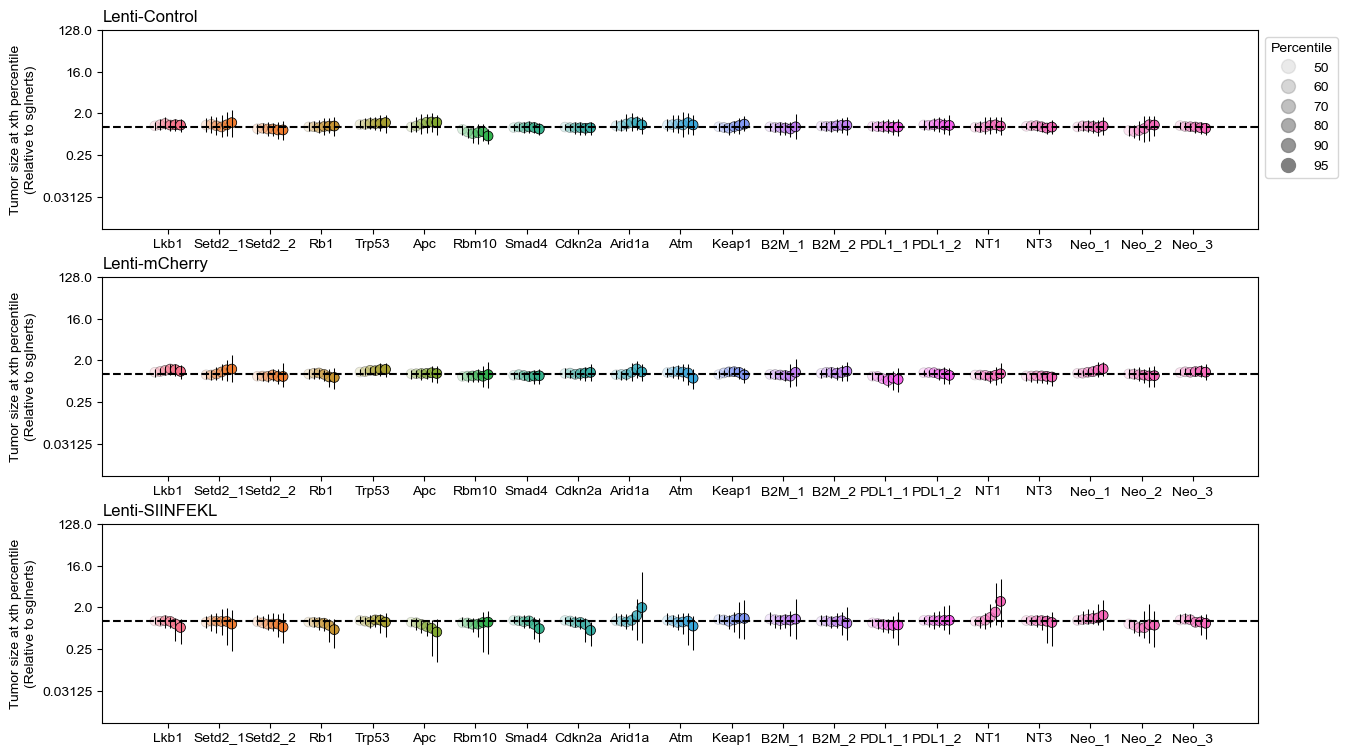

In [23]:
# Part 2 

# Grid specification
gs = gridspec.GridSpec(temp_grid_column, 6)

# Set figure size
fig1 = plt.figure(figsize=input_size)
temp_axis_df = temp_df_list[0]

# Set the first panel axis
ax1 = fig1.add_subplot(gs[:5, 0:5])

# Record the categorical order of legend_group_trait for consistent plotting
order = predefined_order
temp_axis_df[legend_group_trait] = pd.Categorical(temp_axis_df[legend_group_trait], ordered=True, categories=order)

# Reorder the dataframe for plotting
temp_axis_df = temp_axis_df.sort_values(by=[legend_group_trait, group_trait, trait_of_interest], ascending=[True, True, False])
# Melt the dataframe for plotting
temp_q_list0 = [str(x) + '_percentile_relative_bootstrap_median' for x in input_percentile]
temp_q_list1 = [x.split('_bootstrap_median')[0] + '_2.5P' for x in temp_q_list0]
temp_q_list2 = [x.split('_bootstrap_median')[0] + '_97.5P' for x in temp_q_list0]
temp_sub = pd.melt(temp_axis_df, id_vars=['gRNA', 'Targeted_gene_name', 'Numbered_gene_name'],
                   value_vars=temp_q_list0 + temp_q_list1 + temp_q_list2)
temp_sub['X_label'] = temp_sub['Numbered_gene_name'] + '_' + temp_sub['variable']
order_x = temp_sub['Numbered_gene_name'].unique()
temp_sub['Numbered_gene_name'] = pd.Categorical(temp_sub['Numbered_gene_name'], ordered=True, categories=order_x)
temp_sub = temp_sub.sort_values(by=['Numbered_gene_name', 'X_label'])
temp_sub['Percentile_label'] = temp_sub['variable'].apply(lambda x: x.split('_percentile')[0])
temp_sub0 = temp_sub[temp_sub['variable'].isin(temp_q_list0)].copy()
temp_sub1 = temp_sub[temp_sub['variable'].isin(temp_q_list1)].copy()
temp_sub2 = temp_sub[temp_sub['variable'].isin(temp_q_list2)].copy()

# Generate new axis positions for plotting
temp_g = temp_sub0.groupby(['Numbered_gene_name'], as_index=False)['value'].count()
order3 = list(dict.fromkeys(temp_sub0['Numbered_gene_name'].values))
temp_g['Numbered_gene_name'] = pd.Categorical(temp_g['Numbered_gene_name'], ordered=True, categories=order3)
temp_g = temp_g.sort_values(by=['Numbered_gene_name'], ascending=True)

# Create new axis positions
temp_new_axis = []
simple_axis = []
for n, sgRNA_count in enumerate(temp_g['value'].values):
    x = n + 1
    temp_list = generate_symmetric_list(sgRNA_count) + x
    temp_new_axis += list(temp_list)
    simple_axis.append(x)
temp_sub0['New_axis'] = temp_new_axis

# Generate color opacity based on the percentile label
temp_op = [opacity_dic.get(x) for x in temp_sub0['Percentile_label']]

# Plot error bars and scatter plot
ax1.errorbar(temp_sub0['New_axis'], temp_sub0['value'],
             yerr=[np.array(temp_sub0['value'].tolist()) - np.array(temp_sub1['value'].tolist()),
                   np.array(temp_sub2['value'].tolist()) - np.array(temp_sub0['value'].tolist())],
             elinewidth=0.75, linestyle='', color='black')

sns.scatterplot(x='New_axis', y='value', hue=legend_group_trait,
                data=temp_sub0, alpha=temp_op, ax=ax1, s=dot_size,edgecolor='black')

# Customize axes ticks and labels
ax1.set_xticklabels(temp_g['Numbered_gene_name'])
ax1.set_xticks(simple_axis)
ax1.axhline(y=1, color='black', linestyle='--')

# Set y-axis limits and scale
ax1.set_ylim(temp_min_y, temp_max_y)
if logy:
    ax1.set_yscale('log', base=2)
    temp_ticks_list = ax1.get_yticks()
    ax1.set_yticklabels(temp_ticks_list)

# Set axis labels and title
ax1.set_xlabel(None)
ax1.set_ylabel(temp_y_label_name)
ax1.set_title(list_of_vector_type[0], loc='left')

# Rotate x-axis tick labels
# ax1.tick_params(axis='x', labelrotation=90)
if xlabel_fontsize:
    ax1.tick_params(axis='x', which='major', labelsize=xlabel_fontsize)

# Add legend for alpha values
handles = [lines.Line2D([0], [0], marker='o', color='grey', alpha=opacity_dic[key], markersize=10, linestyle='None', label=key)
           for key in opacity_dic]
ax1.legend(handles=handles, title="Percentile", loc='upper left', bbox_to_anchor=(1, 1))
# ax1.tick_params(axis='x', labelbottom=False)  # Hide x-axis labels for the first subplot
# Plot the remaining dataframes
for c, input_df2 in enumerate(temp_df_list[1:]):
    # Set the subsequent panel axes
    ax2 = fig1.add_subplot(gs[(c + 1) * 6:(c + 1) * 6 + 5, 0:5])

    order = predefined_order
    temp_df2 = input_df2.copy()
    # Record the categorical order for consistent plotting
    temp_df2[legend_group_trait] = pd.Categorical(temp_df2[legend_group_trait], ordered=True, categories=order)

    # Reorder the dataframe
    temp_df2 = temp_df2.sort_values(by=[legend_group_trait, group_trait, trait_of_interest], ascending=[True, True, False])

    # Melt the dataframe for plotting
    temp_sub = pd.melt(temp_df2, id_vars=['gRNA', 'Targeted_gene_name', 'Numbered_gene_name'],
                       value_vars=temp_q_list0 + temp_q_list1 + temp_q_list2)
    temp_sub['X_label'] = temp_sub['Numbered_gene_name'] + '_' + temp_sub['variable']
    temp_sub['Numbered_gene_name'] = pd.Categorical(temp_sub['Numbered_gene_name'], ordered=True, categories=order_x)
    temp_sub = temp_sub.sort_values(by=['Numbered_gene_name', 'X_label'])
    temp_sub['Percentile_label'] = temp_sub['variable'].apply(lambda x: x.split('_percentile')[0])
    temp_sub0 = temp_sub[temp_sub['variable'].isin(temp_q_list0)].copy()
    temp_sub1 = temp_sub[temp_sub['variable'].isin(temp_q_list1)].copy()
    temp_sub2 = temp_sub[temp_sub['variable'].isin(temp_q_list2)].copy()

    # Reorder gene order in temp_g to match with temp_df2
    temp_g['Numbered_gene_name'] = pd.Categorical(temp_g['Numbered_gene_name'], ordered=True, categories=order3)
    temp_g = temp_g.sort_values(by=['Numbered_gene_name'], ascending=True)

    # Assign new axis positions for plotting
    temp_sub0['New_axis'] = temp_new_axis

    # Plot error bars and scatter plot
    ax2.errorbar(temp_sub0['New_axis'], temp_sub0['value'],
                 yerr=[np.array(temp_sub0['value'].tolist()) - np.array(temp_sub1['value'].tolist()),
                       np.array(temp_sub2['value'].tolist()) - np.array(temp_sub0['value'].tolist())],
                 elinewidth=0.75, linestyle='', color='black')

    sns.scatterplot(x='New_axis', y='value', hue=legend_group_trait,
                    data=temp_sub0, alpha=temp_op, ax=ax2, s=dot_size, edgecolor='black')

    # Customize axes ticks and labels
    ax2.set_xticklabels(temp_g['Numbered_gene_name'])
    ax2.set_xticks(simple_axis)
    ax2.axhline(y=1, color='black', linestyle='--')
    # Remove x-axis labels for all but the last subplot
        
    # Set y-axis limits and scale
    ax2.set_ylim(temp_min_y, temp_max_y)
    if logy:
        ax2.set_yscale('log', base=2)
        temp_ticks_list = ax2.get_yticks()
        ax2.set_yticklabels(temp_ticks_list)

    # Set axis labels and title
    ax2.set_xlabel(None)
    ax2.set_ylabel(temp_y_label_name)
    ax2.set_title(list_of_vector_type[c + 1], loc='left')

    # Rotate x-axis tick labels
    # ax2.tick_params(axis='x', labelrotation=90)
    if xlabel_fontsize:
        ax2.tick_params(axis='x', which='major', labelsize=xlabel_fontsize)

    # Hide legend for this subplot
    ax2.legend([], [], frameon=False)

# Save the figure
# fig1.savefig(temp_out_address1_s2)

---

## 8 gRNA percentile plot (KC): Fig. S13F

In [24]:
temp_a = 'data/Normal_BT_gRNA_level_summary_df.csv'
query_df = pd.read_csv(temp_a)
query_df = query_df[query_df.Mouse_genotype=='KC']
query_gene_list = ['Lkb1','Setd2','Rb1','Trp53','Apc', 'Rbm10',
                   'Smad4','Cdkn2a','Arid1a','Atm','Keap1','B2M','PDL1','Inert']
sgRNA_df = query_df[(query_df.Targeted_gene_name.isin(query_gene_list))].copy()
sgRNA_df['Targeted_gene_name'] = pd.Categorical(sgRNA_df['Targeted_gene_name'], ordered=True, categories=query_gene_list)
sgRNA_df = sgRNA_df.sort_values(by=['Vector_type','Targeted_gene_name'], ascending=[True, True]).copy()

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec, lines
import seaborn as sns
import numpy as np

# Input dataframe
input_df = query_df

# List of genotypes to analyze
list_of_vector_type = ['Lenti-Control', 'Lenti-mCherry', 'Lenti-SIINFEKL']

# Cutoff values for each genotype
list_of_cutoff = [100, 100, 100]

predefined_order = query_gene_list
list_of_genotype = list_of_vector_type
# Genes of interest
goi = predefined_order

# Trait of interest for analysis
trait_of_interest = 'LN_mean_relative'

def generate_symmetric_list(input_n):
    """Generate a symmetric list of values for axis positioning."""
    if input_n % 2 == 1:
        return np.array(range(-int((input_n - 1) / 2), int((input_n + 1) / 2))) * 0.1
    else:
        return np.array(range(-int(input_n / 2), int(input_n / 2))) * 0.1 + 0.05

# Generate dataframes for each genotype and concatenate them
temp_df_list = []
for genotype in list_of_genotype:
    temp_df = input_df[(input_df.Vector_type == genotype)]
    temp_df = temp_df[temp_df.Targeted_gene_name.isin(goi)]
    temp_df_list.append(temp_df)
temp_final_df = pd.concat(temp_df_list, ignore_index=True)

# Decide figure size based on the number of genes and genotypes
input_size = (len(goi) + 4, len(list_of_vector_type) * 3)

# Grid configuration for the plots
temp_grid_column = len(list_of_vector_type) * 6 - 1

# Determine the y-axis limits
temp_min_y = 0.00625
temp_max_y = 128

# Percentiles of interest
input_percentile = [50, 60, 70, 80, 90, 95]

# Generate labels for the percentiles
temp1 = [str(x) for x in input_percentile]

# Split and reverse the percentile array for opacity settings
temp = np.array_split((np.array(range(1, 101)) / 100)[::-1], len(temp1))
temp2 = [x[0] for x in temp][::-1]

# Create a dictionary for opacity based on percentiles
opacity_dic = dict(zip(temp1, temp2))

# Group traits for legend and plotting
group_trait, legend_group_trait, direction = 'Numbered_gene_name', 'Targeted_gene_name', 'up'

# Output settings and plot parameters
output_address = None
logy = True
legend_row = 2

# Axis label size
xlabel_fontsize = 10

# y-axis label name
temp_y_label_name = 'Tumor size at xth percentile\n(Relative to sgInerts)'

# x-axis label name
temp_x_label_name = 'Target gene'

# Dot size for the scatter plot
dot_size = 50


/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/2563434354.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_g = temp_sub0.groupby(['Numbered_gene_name'], as_index=False)['value'].count()
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/2563434354.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(temp_g['Numbered_gene_name'])
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/2563434354.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(temp_ticks_list)
/var/folders/xv/26kbh4lj2rjdcrxz37m9wxyw0000gn/T/ipykernel_24256/2563434354.py:130

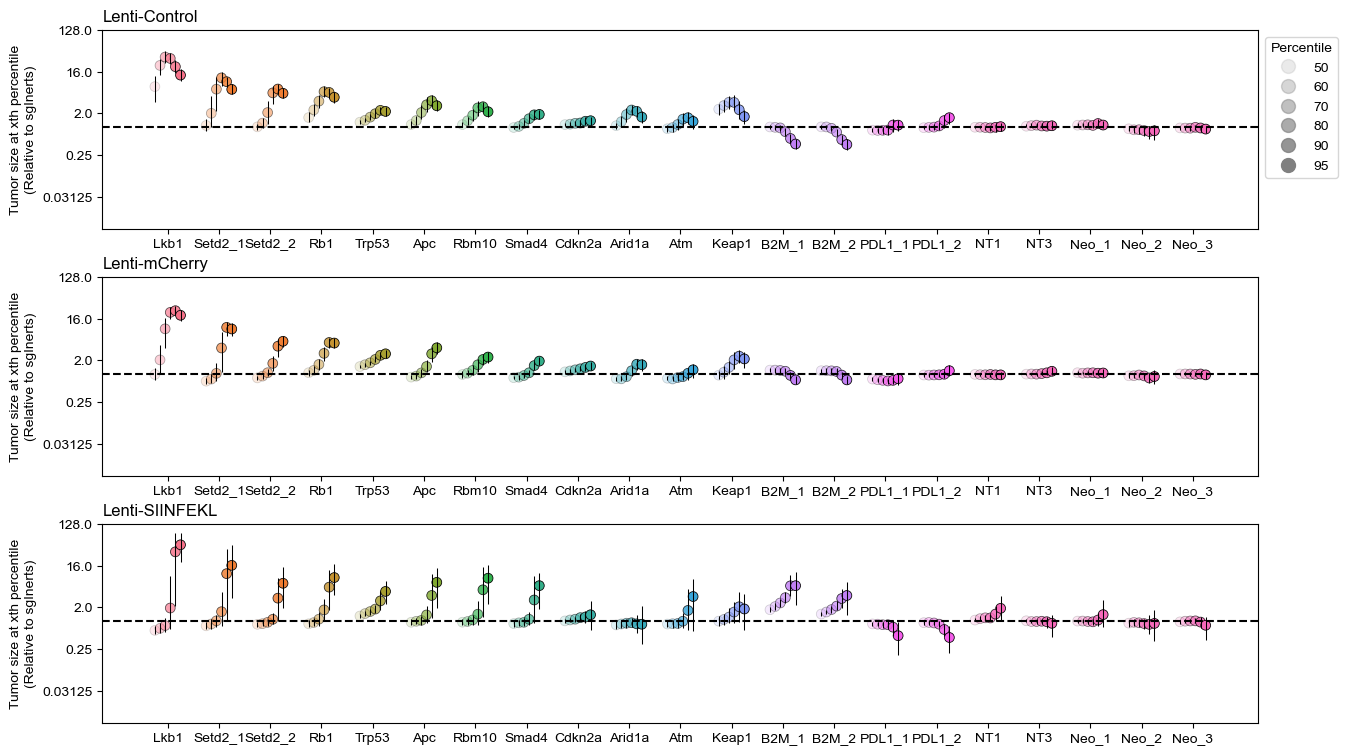

In [26]:
# Part 2 

# Grid specification
gs = gridspec.GridSpec(temp_grid_column, 6)

# Set figure size
fig1 = plt.figure(figsize=input_size)
temp_axis_df = temp_df_list[0]

# Set the first panel axis
ax1 = fig1.add_subplot(gs[:5, 0:5])

# Record the categorical order of legend_group_trait for consistent plotting
order = predefined_order
temp_axis_df[legend_group_trait] = pd.Categorical(temp_axis_df[legend_group_trait], ordered=True, categories=order)

# Reorder the dataframe for plotting
temp_axis_df = temp_axis_df.sort_values(by=[legend_group_trait, group_trait, trait_of_interest], ascending=[True, True, False])
# Melt the dataframe for plotting
temp_q_list0 = [str(x) + '_percentile_relative_bootstrap_median' for x in input_percentile]
temp_q_list1 = [x.split('_bootstrap_median')[0] + '_2.5P' for x in temp_q_list0]
temp_q_list2 = [x.split('_bootstrap_median')[0] + '_97.5P' for x in temp_q_list0]
temp_sub = pd.melt(temp_axis_df, id_vars=['gRNA', 'Targeted_gene_name', 'Numbered_gene_name'],
                   value_vars=temp_q_list0 + temp_q_list1 + temp_q_list2)
temp_sub['X_label'] = temp_sub['Numbered_gene_name'] + '_' + temp_sub['variable']
order_x = temp_sub['Numbered_gene_name'].unique()
temp_sub['Numbered_gene_name'] = pd.Categorical(temp_sub['Numbered_gene_name'], ordered=True, categories=order_x)
temp_sub = temp_sub.sort_values(by=['Numbered_gene_name', 'X_label'])
temp_sub['Percentile_label'] = temp_sub['variable'].apply(lambda x: x.split('_percentile')[0])
temp_sub0 = temp_sub[temp_sub['variable'].isin(temp_q_list0)].copy()
temp_sub1 = temp_sub[temp_sub['variable'].isin(temp_q_list1)].copy()
temp_sub2 = temp_sub[temp_sub['variable'].isin(temp_q_list2)].copy()

# Generate new axis positions for plotting
temp_g = temp_sub0.groupby(['Numbered_gene_name'], as_index=False)['value'].count()
order3 = list(dict.fromkeys(temp_sub0['Numbered_gene_name'].values))
temp_g['Numbered_gene_name'] = pd.Categorical(temp_g['Numbered_gene_name'], ordered=True, categories=order3)
temp_g = temp_g.sort_values(by=['Numbered_gene_name'], ascending=True)

# Create new axis positions
temp_new_axis = []
simple_axis = []
for n, sgRNA_count in enumerate(temp_g['value'].values):
    x = n + 1
    temp_list = generate_symmetric_list(sgRNA_count) + x
    temp_new_axis += list(temp_list)
    simple_axis.append(x)
temp_sub0['New_axis'] = temp_new_axis

# Generate color opacity based on the percentile label
temp_op = [opacity_dic.get(x) for x in temp_sub0['Percentile_label']]

# Plot error bars and scatter plot
ax1.errorbar(temp_sub0['New_axis'], temp_sub0['value'],
             yerr=[np.array(temp_sub0['value'].tolist()) - np.array(temp_sub1['value'].tolist()),
                   np.array(temp_sub2['value'].tolist()) - np.array(temp_sub0['value'].tolist())],
             elinewidth=0.75, linestyle='', color='black')

sns.scatterplot(x='New_axis', y='value', hue=legend_group_trait,
                data=temp_sub0, alpha=temp_op, ax=ax1, s=dot_size,edgecolor='black')

# Customize axes ticks and labels
ax1.set_xticklabels(temp_g['Numbered_gene_name'])
ax1.set_xticks(simple_axis)
ax1.axhline(y=1, color='black', linestyle='--')

# Set y-axis limits and scale
ax1.set_ylim(temp_min_y, temp_max_y)
if logy:
    ax1.set_yscale('log', base=2)
    temp_ticks_list = ax1.get_yticks()
    ax1.set_yticklabels(temp_ticks_list)

# Set axis labels and title
ax1.set_xlabel(None)
ax1.set_ylabel(temp_y_label_name)
ax1.set_title(list_of_vector_type[0], loc='left')

# Rotate x-axis tick labels
# ax1.tick_params(axis='x', labelrotation=90)
if xlabel_fontsize:
    ax1.tick_params(axis='x', which='major', labelsize=xlabel_fontsize)

# Add legend for alpha values
handles = [lines.Line2D([0], [0], marker='o', color='grey', alpha=opacity_dic[key], markersize=10, linestyle='None', label=key)
           for key in opacity_dic]
ax1.legend(handles=handles, title="Percentile", loc='upper left', bbox_to_anchor=(1, 1))
# ax1.tick_params(axis='x', labelbottom=False)  # Hide x-axis labels for the first subplot
# Plot the remaining dataframes
for c, input_df2 in enumerate(temp_df_list[1:]):
    # Set the subsequent panel axes
    ax2 = fig1.add_subplot(gs[(c + 1) * 6:(c + 1) * 6 + 5, 0:5])

    order = predefined_order
    temp_df2 = input_df2.copy()
    # Record the categorical order for consistent plotting
    temp_df2[legend_group_trait] = pd.Categorical(temp_df2[legend_group_trait], ordered=True, categories=order)

    # Reorder the dataframe
    temp_df2 = temp_df2.sort_values(by=[legend_group_trait, group_trait, trait_of_interest], ascending=[True, True, False])

    # Melt the dataframe for plotting
    temp_sub = pd.melt(temp_df2, id_vars=['gRNA', 'Targeted_gene_name', 'Numbered_gene_name'],
                       value_vars=temp_q_list0 + temp_q_list1 + temp_q_list2)
    temp_sub['X_label'] = temp_sub['Numbered_gene_name'] + '_' + temp_sub['variable']
    temp_sub['Numbered_gene_name'] = pd.Categorical(temp_sub['Numbered_gene_name'], ordered=True, categories=order_x)
    temp_sub = temp_sub.sort_values(by=['Numbered_gene_name', 'X_label'])
    temp_sub['Percentile_label'] = temp_sub['variable'].apply(lambda x: x.split('_percentile')[0])
    temp_sub0 = temp_sub[temp_sub['variable'].isin(temp_q_list0)].copy()
    temp_sub1 = temp_sub[temp_sub['variable'].isin(temp_q_list1)].copy()
    temp_sub2 = temp_sub[temp_sub['variable'].isin(temp_q_list2)].copy()

    # Reorder gene order in temp_g to match with temp_df2
    temp_g['Numbered_gene_name'] = pd.Categorical(temp_g['Numbered_gene_name'], ordered=True, categories=order3)
    temp_g = temp_g.sort_values(by=['Numbered_gene_name'], ascending=True)

    # Assign new axis positions for plotting
    temp_sub0['New_axis'] = temp_new_axis

    # Plot error bars and scatter plot
    ax2.errorbar(temp_sub0['New_axis'], temp_sub0['value'],
                 yerr=[np.array(temp_sub0['value'].tolist()) - np.array(temp_sub1['value'].tolist()),
                       np.array(temp_sub2['value'].tolist()) - np.array(temp_sub0['value'].tolist())],
                 elinewidth=0.75, linestyle='', color='black')

    sns.scatterplot(x='New_axis', y='value', hue=legend_group_trait,
                    data=temp_sub0, alpha=temp_op, ax=ax2, s=dot_size, edgecolor='black')

    # Customize axes ticks and labels
    ax2.set_xticklabels(temp_g['Numbered_gene_name'])
    ax2.set_xticks(simple_axis)
    ax2.axhline(y=1, color='black', linestyle='--')
    # Remove x-axis labels for all but the last subplot
        
    # Set y-axis limits and scale
    ax2.set_ylim(temp_min_y, temp_max_y)
    if logy:
        ax2.set_yscale('log', base=2)
        temp_ticks_list = ax2.get_yticks()
        ax2.set_yticklabels(temp_ticks_list)

    # Set axis labels and title
    ax2.set_xlabel(None)
    ax2.set_ylabel(temp_y_label_name)
    ax2.set_title(list_of_vector_type[c + 1], loc='left')

    # Rotate x-axis tick labels
    # ax2.tick_params(axis='x', labelrotation=90)
    if xlabel_fontsize:
        ax2.tick_params(axis='x', which='major', labelsize=xlabel_fontsize)

    # Hide legend for this subplot
    ax2.legend([], [], frameon=False)

# Save the figure
# fig1.savefig(temp_out_address1_s)